In [1]:
import geojson
import geopandas as gpd
import rasterio
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import firedrake
from firedrake import Constant, inner, jump, grad, dx, avg, dS, min_value, max_value, conditional, pi
import icepack
from matplotlib.colors import LinearSegmentedColormap
import irksome
from irksome import Dt
import cmcrameri.cm as cmc
from cmcrameri import show_cmaps
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FormatStrFormatter)

# Load in Emmons Files:

In [2]:
outline_filename = '../data/emmons_outine/emmons_1896_full.geojson'

m1_h = '../data/Thickness/m1-thickness_RGI60-02.14297.tif'
m2_h = '../data/Thickness/m2-thickness_RGI60-02.14297.tif' # Best looking thickness map w/ most logical values
m3_h = '../data/Thickness/m3-thickness_RGI60-02.14297.tif'

farinotti_surface = '../data/surfaces/surface_DEM_RGI60-02.14297.tif'
dave_surface = '../data/surfaces/emmonsSurf_DBM2.tif'

quinn_velo = '../data/Velocity/quinn_velo/rasters/S2_MJJAS_median_horizontal_velocity.tif'
quinn_WinVelo = '../data/Velocity/quinn_velo/rasters/S2_NDJFM_median_horizontal_velocity.tif'

dave_bed = '../data/surfaces/emmons_bed_daveNewClip.tif' 

## Make mesh

In [3]:
with open(outline_filename, "r") as outline_file:
    outline = geojson.load(outline_file)

In [4]:
gmsh_mesh = icepack.meshing.collection_to_gmsh(outline)
gmsh_mesh.write("emmons.msh", verbose=False)

mesh = firedrake.Mesh("emmons.msh") # Initial mesh

In [5]:
from firedrake.mg.mesh import MeshHierarchy

mesh0 = firedrake.Mesh('emmons.msh')
hierarchy = MeshHierarchy(mesh0, 3, 1) 
mesh = hierarchy[0] 

In [6]:
# This cell is gold for things later
cell_sizes = mesh.cell_sizes.dat.data_ro

print(f'Cells: {mesh.num_cells()}')
print(f'Min: {cell_sizes.min()} m')
print(f'Max: {cell_sizes.max()} m')
print(f'Avg: {cell_sizes.mean()} m')

Cells: 1128
Min: 67.35122523951948 m
Max: 731.3741104652709 m
Avg: 218.05080437559553 m


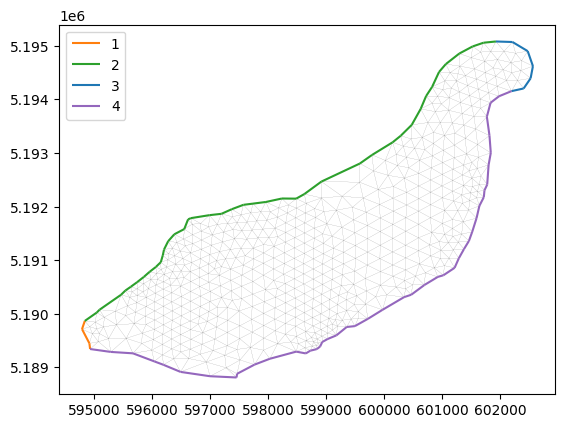

In [7]:
fig, axes = plt.subplots()
kw = {
    "boundary_kw": {"colors": ["tab:orange", "tab:green", "tab:blue", "tab:purple"]},
    "interior_kw": {"linewidth": 0.03}, # Change lw val to smaller number to make boundaries easier to see
}
firedrake.triplot(mesh, axes=axes, **kw)
axes.legend(loc="upper left");

In [8]:
## Function Spaces
dg1 = firedrake.FiniteElement("DG", "triangle", 1)
cg1 = firedrake.FiniteElement("CG", "triangle", 1)

Q = firedrake.FunctionSpace(mesh, dg1) 
V = firedrake.VectorFunctionSpace(mesh, cg1)

# Plot each to see if they all line up

In [9]:
coords = np.array(list(geojson.utils.coords(outline)))
delta = 1e3
extent = {
    "left": coords[:, 0].min() - 1 * delta,
    "right": coords[:, 0].max() + delta,
    "bottom": coords[:, 1].min() - 1 * delta,
    "top": coords[:, 1].max() + delta,
}

In [10]:
# Surface File (Farinotti, not going to use)
surf_file = rasterio.open(dave_surface)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=surf_file.transform).round_lengths().round_offsets()
transform = surf_file.window_transform(window)
FarinottiSurf_obs = surf_file.read(window=window)

surf_file = rasterio.open(dave_surface)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=surf_file.transform).round_lengths().round_offsets()
transform = surf_file.window_transform(window)
DaveSurf_obs = surf_file.read(window=window)

# Filtering Fill Vals
DaveSurf_obs[DaveSurf_obs < 0] = 0

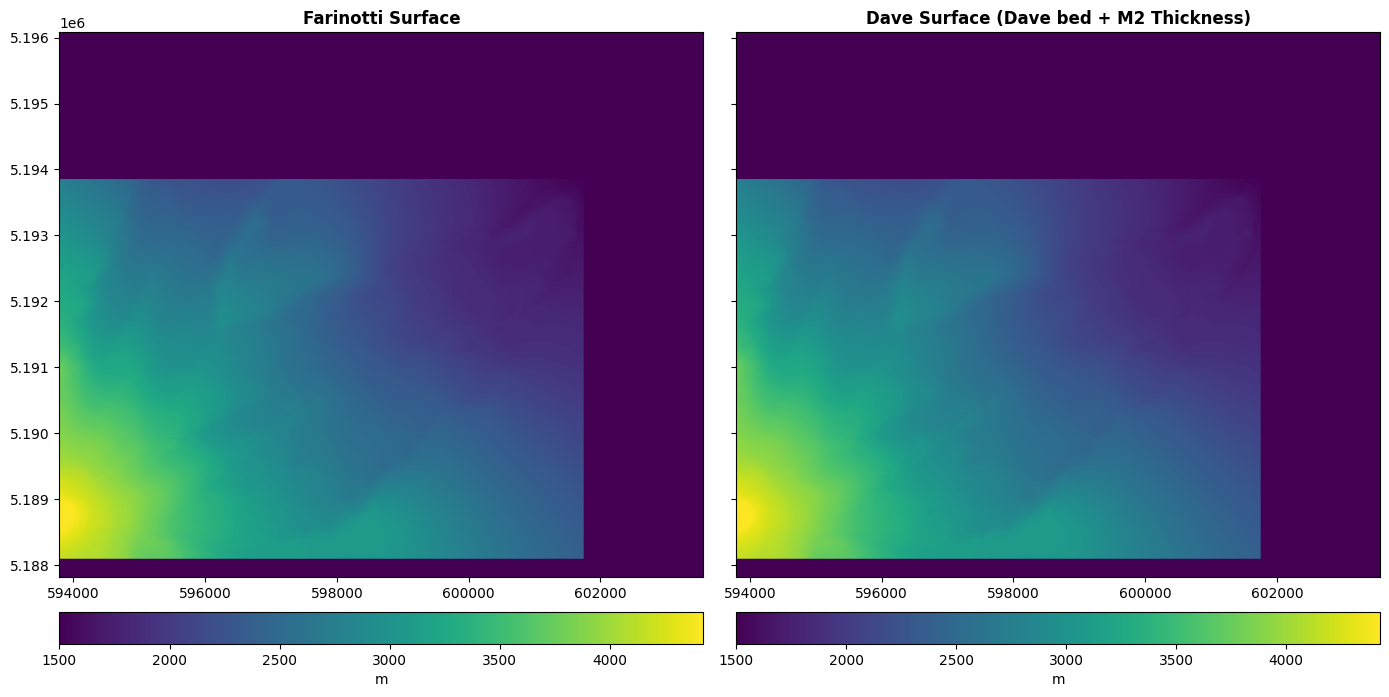

In [11]:
fig, ax = plt.subplots(1, 2, figsize = [14, 12], sharey = True)

colors = ax[0].imshow(FarinottiSurf_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      #cmap = cmap2,
                      vmin = 1500,
                      axes=ax[0])
fig.colorbar(colors, label="m", location = 'bottom', fraction=0.046, pad=0.03)
ax[0].set_title('Farinotti Surface', fontweight = 'bold')
ax[0].set_aspect("equal")

colors = ax[1].imshow(DaveSurf_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      #cmap = cmap2,
                      vmin = 1500,                        
                      axes=ax[1])
fig.colorbar(colors, label="m", location = 'bottom', fraction=0.046, pad=0.03)
ax[1].set_title('Dave Surface (Dave bed + M2 Thickness)', fontweight = 'bold')
ax[1].set_aspect("equal")

plt.tight_layout()

In [12]:
# Bed File
bed_file = rasterio.open(dave_bed)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=bed_file.transform).round_lengths().round_offsets()
transform = bed_file.window_transform(window)
b_obs = bed_file.read(window=window)

# Filtering Fill Vals
b_obs = b_obs[0, :, :]
b_obs[b_obs < 0] = 0

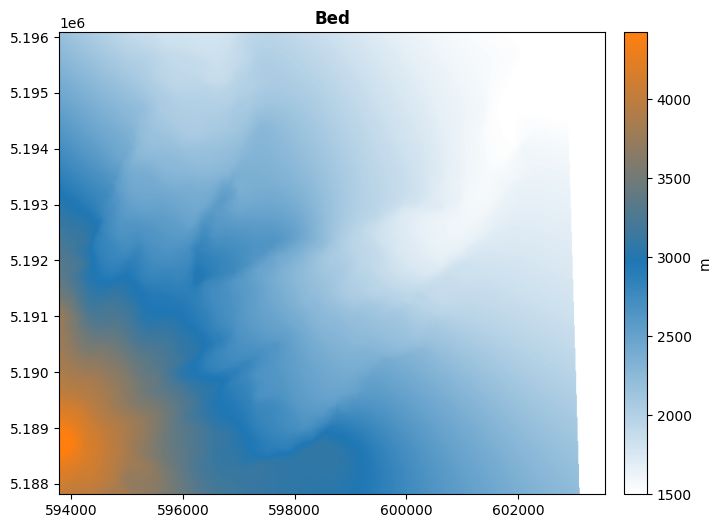

In [13]:
# Bed Plot
cmap3 = LinearSegmentedColormap.from_list('', ['white', 'tab:blue', 'tab:orange'])

fig, ax = plt.subplots(figsize = [8, 6])
#firedrake.triplot(mesh, axes=ax)
colors = ax.imshow(b_obs, 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap3,
                      vmin = 1500,
                      axes=ax)
fig.colorbar(colors, label="m", location = 'right', fraction=0.046, pad=0.03)
ax.set_title('Bed', fontweight = 'bold')
ax.set_aspect("equal")

In [14]:
# Thickness Files (Model est. from Farinotti)
m1_file = rasterio.open(m1_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=m1_file.transform).round_lengths().round_offsets()
transform = m1_file.window_transform(window)
m1_obs = m1_file.read(window=window)

m2_file = rasterio.open(m2_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=m2_file.transform).round_lengths().round_offsets()
transform = m2_file.window_transform(window)
m2_obs = m2_file.read(window=window)

m3_file = rasterio.open(m3_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=m3_file.transform).round_lengths().round_offsets()
transform = m3_file.window_transform(window)
m3_obs = m3_file.read(window=window)


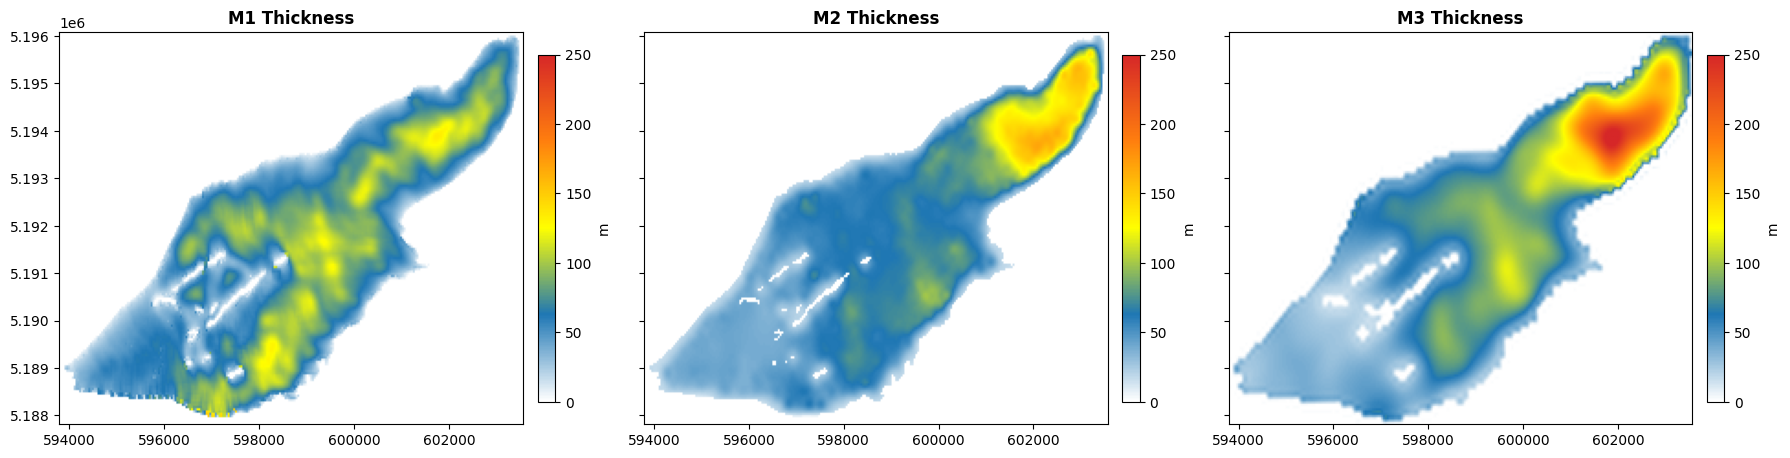

In [15]:
# Thickess Plts
cmap2 = LinearSegmentedColormap.from_list('', ['white', 'tab:blue', 'yellow', 'tab:orange', 'tab:red'])

fig, ax = plt.subplots(1, 3, figsize = [18, 16], sharey = True)

colors = ax[0].imshow(m1_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 250,
                      axes=ax[0])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[0].set_title('M1 Thickness', fontweight = 'bold')
ax[0].set_aspect("equal")

colors = ax[1].imshow(m2_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 250,                        
                      axes=ax[1])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[1].set_title('M2 Thickness', fontweight = 'bold')
ax[1].set_aspect("equal")

colors = ax[2].imshow(m3_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 250,                        
                      axes=ax[2])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[2].set_title('M3 Thickness', fontweight = 'bold')
ax[2].set_aspect("equal")

plt.tight_layout()

In [16]:
# Quinn Velocity Plot
velo_file = rasterio.open(quinn_velo)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=velo_file.transform).round_lengths().round_offsets()
transform = velo_file.window_transform(window)
SumVelo_obs = velo_file.read(window=window)

In [17]:
velo_file1 = rasterio.open(quinn_WinVelo)
window1 = rasterio.windows.from_bounds(**extent, 
                                      transform=velo_file1.transform).round_lengths().round_offsets()
transform1 = velo_file1.window_transform(window1)
WinVelo_obs = velo_file1.read(window=window1)

WinVelo_obs[WinVelo_obs > 350] = 75.0

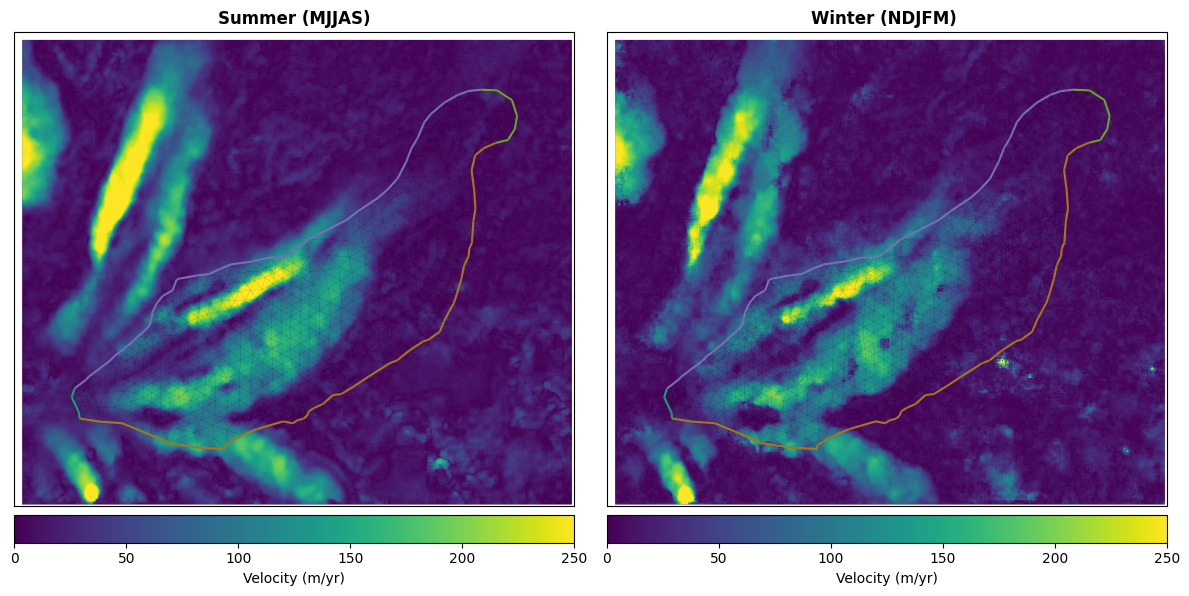

In [18]:
fig, ax = plt.subplots(1, 2, figsize = [12, 10], sharey = True)
#firedrake.triplot(mesh, axes=ax)
colors = ax[0].imshow(SumVelo_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      vmax = 250,
                      axes=ax[0])
fig.colorbar(colors, label="Velocity (m/yr)", location = 'bottom', fraction=0.04, pad=0.009, ax = ax[0])
ax[0].set_title('Summer (MJJAS)', fontweight = 'bold')
ax[0].set_aspect("equal")
firedrake.triplot(mesh, axes=ax[0], **kw)
ax[0].set_xticks([])
ax[0].set_yticks([])

colors1 = ax[1].imshow(WinVelo_obs[0, :, :], 
                      vmax = 250,
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      axes=ax[1])
fig.colorbar(colors1, label="Velocity (m/yr)", location = 'bottom', fraction=0.04, pad=0.009, ax = ax[1])
ax[1].set_title('Winter (NDJFM) ', fontweight = 'bold')
ax[1].set_aspect("equal")
firedrake.triplot(mesh, axes=ax[1], **kw)
ax[1].set_xticks([])
ax[1].set_yticks([])

fig.tight_layout()

### Now that everything is loaded in and aligned we need to do some smoothing and fixing of coords before interpolating to our mesh

In [19]:
def smoove(q_obs, λ):
    q = q_obs.copy(deepcopy=True)
    J = 0.5 * ((q - q_obs)**2 + Constant(λ)**2 * inner(grad(q), grad(q))) * dx
    F = firedrake.derivative(J, q)
    firedrake.solve(F == 0, q)
    return q

def fix_obs(field):
    coord_dims = field.shape

    xs = np.linspace(extent['left'], extent['right'], coord_dims[1])
    ys = np.linspace(extent['bottom'], extent['top'], coord_dims[0])

    field_new = xr.DataArray(field, 
                  dims=("y", "x"), 
                  coords={"x": xs , "y": ys[::-1]})

    return field_new


λ = 8e3

In [20]:
m2 = fix_obs(m2_obs[0, :, :])
h_o = icepack.interpolate(m2, Q)
h0_m2 = firedrake.project(smoove(h_o, λ), Q)

s_d = fix_obs(DaveSurf_obs[0, :, :])
s_o = icepack.interpolate(s_d, Q)
s0_dave = firedrake.project(smoove(s_o, λ), Q)

b_d = fix_obs(b_obs)
b_o = icepack.interpolate(b_d, Q)
b0_dave = firedrake.project(smoove(b_o, λ), Q)

v_d = fix_obs(SumVelo_obs[0, :, :])
v_o = icepack.interpolate(v_d, Q)
vs0 = firedrake.project(smoove(v_o, λ), Q)

v_d = fix_obs(WinVelo_obs[0, :, :])
v_o = icepack.interpolate(v_d, Q)
vw0 = firedrake.project(smoove(v_o, λ), Q)

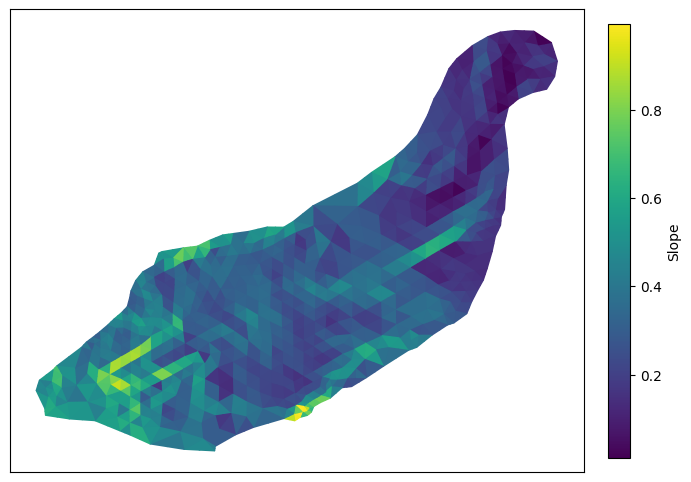

In [21]:
dg0 = firedrake.FiniteElement("DG", "triangle", 0)

S = firedrake.FunctionSpace(mesh, cg1) 
B = firedrake.VectorFunctionSpace(mesh, dg0)

b_o = icepack.interpolate(b_d, S)
bSlope_dave = firedrake.project(grad(b_o), B)

s_o = icepack.interpolate(s_d, S)
slope_dave = firedrake.project(grad(s_o), B)

fig, ax = plt.subplots(figsize = [8, 8])

colors = firedrake.tripcolor(bSlope_dave, axes=ax)
fig.colorbar(colors, label="Slope", location = 'right', fraction=0.035, pad=0.04)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

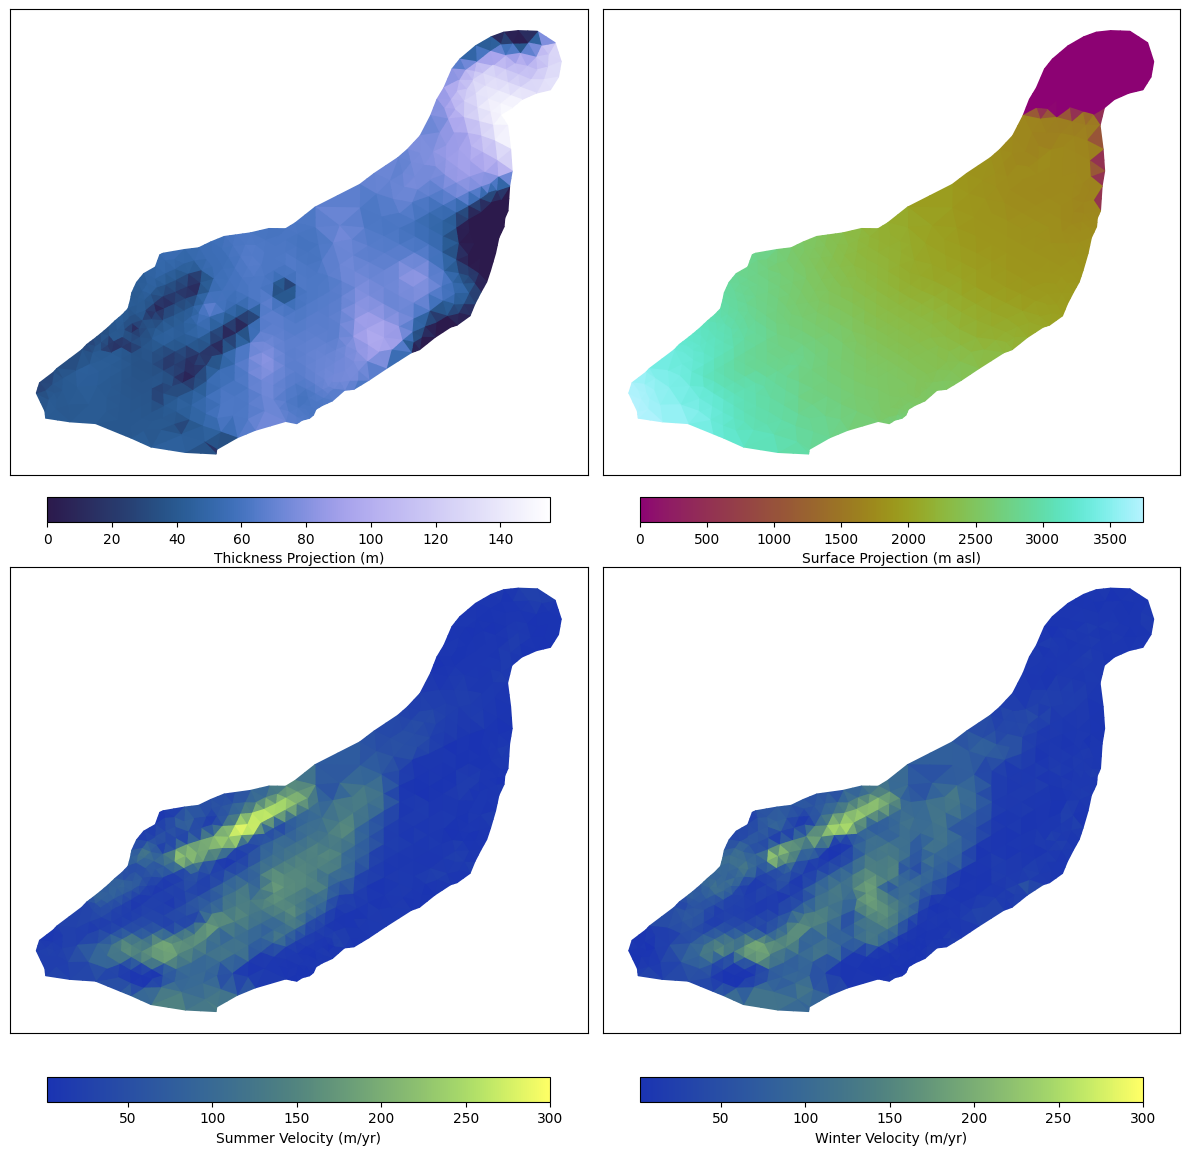

In [22]:
fig, ax = plt.subplots(2, 2, figsize = [12, 12], sharex = True, sharey = True)

colors = firedrake.tripcolor(h0_m2, 
                      cmap = cmc.devon,
                      axes=ax[0,0])
fig.colorbar(colors, label="Thickness Projection (m)", location = 'bottom', fraction=0.046, pad=0.04)
ax[0,0].set_aspect("equal")
ax[0,0].xaxis.set_minor_locator(AutoMinorLocator())
ax[0,0].tick_params(which='both')
ax[0,0].tick_params(which='major')
ax[0,0].tick_params(which='minor')
ax[0,0].yaxis.set_minor_locator(AutoMinorLocator())

ax[0,0].grid()
ax[0,0].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

colors = firedrake.tripcolor(s0_dave, 
                              axes=ax[0,1], 
                              cmap = cmc.hawaii
                             )
fig.colorbar(colors, label="Surface Projection (m asl)", location = 'bottom',fraction=0.046, pad=0.04)

ax[0,1].set_aspect("equal")

colors = firedrake.tripcolor(vs0, 
                             vmax = 300,
                             cmap = cmc.imola,
                             axes=ax[1,0])
ax[0,1].grid()
ax[0,1].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

fig.colorbar(colors, label="Summer Velocity (m/yr)", location = 'bottom',fraction=0.046, pad=0.08)
ax[1,0].set_aspect("equal")


colors = firedrake.tripcolor(vw0, 
                             vmax = 300, 
                             cmap = cmc.imola,
                             axes=ax[1,1])
fig.colorbar(colors, label="Winter Velocity (m/yr)", location = 'bottom',fraction=0.046, pad=0.08)
ax[1,1].set_aspect("equal")

ax[0,0].set_xticks([])
ax[0,1].set_xticks([])
ax[1,0].set_xticks([])
ax[1,1].set_xticks([])

ax[1,0].set_yticks([])
fig.tight_layout()
#fig.savefig('inputs.png', bbox_inches='tight', dpi = 300)

#basemap, north arrow, scale bar

## Initial Solves (SIA vs. Hybrid)

In [23]:
from icepack2.constants import gravity, ice_density, glen_flow_law
A = icepack.rate_factor(Constant(279.15)) 

In [24]:
icepack.rate_factor(279.15) / icepack.rate_factor(273.15) # enhancement factor

np.float64(3.726638696289609)

In [25]:
h0 = h0_m2
s0 = s0_dave

In [26]:
from icepack2.constants import gravity as g, ice_density as ρ_I, glen_flow_law, water_density as ρ_W

# Method for DG0 surface
ρ = Constant(ρ_I)
g = Constant(g)
ρ_W = Constant(ρ_W)

τ_d = firedrake.Function(V)
σ = firedrake.TestFunction(V)
ν = firedrake.FacetNormal(mesh)

F_cells = (inner(τ_d, σ) + ρ*g*h0 * inner(grad(s0), σ)) * dx
F_facets = -inner(avg(ρ*g*h0) * jump(s0, ν), avg(σ)) * dS
F = F_cells + F_facets

firedrake.solve(F == 0, τ_d)

fig, axes = plt.subplots(figsize = (8, 8), sharex = True, sharey = True)

axes.set_aspect("equal")
colors = firedrake.tripcolor(τ_d, 
                             cmap = cmap2, 
                             #vmax = 400, 
                             axes=axes)
fig.colorbar(colors, fraction=0.046, pad=0.05, orientation = 'horizontal')
axes.set_title('SIA τ_d [MPa]', fontweight = 'bold')

In [27]:
from icepack2.constants import gravity as g, ice_density as ρ, glen_flow_law

n = Constant(glen_flow_law)

u_sia = firedrake.Function(V)
v = firedrake.TestFunction(V)

u_shear = (-2/(n+2)) * h0 * A * (inner(τ_d, τ_d) ** 0.5) ** (n-1) * τ_d
F = inner(u_sia - u_shear, v) * dx

solver_params = {"snes_type": "ksponly", "ksp_type": "gmres"}
fc_params = {"quadrature_degree": 6}
params = {"solver_parameters": solver_params, "form_compiler_parameters": fc_params}
firedrake.solve(F == 0, u_sia, **params)

In [28]:
dg0 = firedrake.FiniteElement("DG", "triangle", 0)

u = firedrake.Function(V)

Σ = firedrake.TensorFunctionSpace(mesh, dg0, symmetry=True)
T = firedrake.VectorFunctionSpace(mesh, cg1)
Z = V * Σ * T
z = firedrake.Function(Z)

z.sub(0).assign(u);

In [29]:
h = h0.copy(deepcopy = True)
s = s0.copy(deepcopy = True)
b = b0_dave.copy(deepcopy = True)

### Sliding Law
 This is where we can make param. choices to get SIA or SSA behavior. In this study we want to capture a higher velocity on the emmons due to sliding in the summer. Currently I'm trying to work on getting the sliding param to oscillate seasonally but am running into issues.

In [30]:
τ_c = Constant(0.1) # Critical Stress (set to 0.1 mPa)
ε_c = Constant(A * τ_c ** n) # multiply by very small Λ for SIA-like

K = h * A / (n + 2)

t = Constant(0.0)
U_0 = Constant(20.0)
ΔU = Constant(15.0)

U_c = U_0 + ΔU * firedrake.sin(2 * pi * t)# + ϕ) # Critical velocity -> 0 completely turns of long. stress (SIA-like) 100
#U_c = Constant(8.0) 
u_c = K * τ_c ** n + U_c

In [31]:
glen_rheology = {
    "flow_law_exponent": n,
    "flow_law_coefficient": ε_c / τ_c ** n,
    "sliding_exponent": n,
    "sliding_coefficient": u_c / τ_c ** n,
}

α = firedrake.Constant(1e-4)
linear_rheology = {
    "flow_law_exponent": 1,
    "flow_law_coefficient": ε_c / τ_c,
    "sliding_exponent": 1,
    "sliding_coefficient": u_c / τ_c,
}

u, M, τ = firedrake.split(z)
fields = {
    "velocity": u,
    "membrane_stress": M,
    "basal_stress": τ,
    "thickness": h,
    "surface": s,
}

v, N, σ = firedrake.TestFunctions(Z)

This is where we needed to be careful of the BCs. At the top of the volcano there is a crater that dips back slightly which was causing the solver to crash. We had to set the inflow BC to some small non zero value in order to produce an initial state that ran. After experimenting with this, we eventually got a map that resembles some of the initial states much more closely than before. 

In [32]:
degree = 1
qdegree = max(8, degree ** glen_flow_law)
inflow_ids = [1]
#side_wall_ids = [1, 3]
bc = firedrake.DirichletBC(Z.sub(0), Constant((5.0, 11.0)), inflow_ids)# -----> Inflow set to some velocity prof 5.0, 11.0
pparams = {
    "bcs": bc,
    "form_compiler_parameters": {"quadrature_degree": qdegree},
}

sparams = {
    "solver_parameters": {
        "snes_monitor": None,
        #"snes_linesearch_monitor": None,
        "snes_type": "newtonls",
        "snes_max_it": 200,
        "snes_divergence_tolerance": 1e250,
        "snes_linesearch_type": "l2",
        "snes_linesearch_max_it": 5,
        "ksp_type": "gmres",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
}

In [33]:
from icepack2 import model
from icepack2.model.variational import momentum_balance, flow_law, friction_law

H = Constant(100.0)

F = (
    momentum_balance(**fields, test_function=v)
    + firedrake.replace(flow_law(**fields, **glen_rheology, test_function=N), {h: H})
    + α * firedrake.replace(flow_law(**fields, **linear_rheology, test_function=N), {h: H})
    + friction_law(**fields, **glen_rheology, test_function=σ)
    + α * friction_law(**fields, **linear_rheology, test_function=σ)
)

momentum_problem = firedrake.NonlinearVariationalProblem(F, z, **pparams)
momentum_solver = firedrake.NonlinearVariationalSolver(momentum_problem, **sparams)

In [34]:
num_continuation_steps = 10
for exponent in np.linspace(1.0, 3.0, num_continuation_steps):
    n.assign(exponent)
    momentum_solver.solve()

  0 SNES Function norm 8.850187338345e+05
  1 SNES Function norm 1.039305617702e-06
  0 SNES Function norm 1.040730662574e+09
  1 SNES Function norm 5.842356375844e+07
  2 SNES Function norm 6.110616336402e+05
  3 SNES Function norm 6.305388009140e+03
  4 SNES Function norm 1.901543110182e+00
  0 SNES Function norm 1.004897554051e+09
  1 SNES Function norm 1.013957792897e+08
  2 SNES Function norm 1.028320752320e+06
  3 SNES Function norm 3.510694814214e+03
  4 SNES Function norm 6.207080682146e-01
  0 SNES Function norm 1.314545845643e+09
  1 SNES Function norm 1.407536936288e+08
  2 SNES Function norm 8.820657197273e+05
  3 SNES Function norm 4.682397983514e+03
  4 SNES Function norm 1.326684896712e+01
  5 SNES Function norm 4.893451624120e-04
  0 SNES Function norm 2.039466798932e+09
  1 SNES Function norm 1.785545876362e+08
  2 SNES Function norm 1.096337335716e+06
  3 SNES Function norm 1.164788193356e+04
  4 SNES Function norm 3.469159932452e+01
  5 SNES Function norm 2.226959625

In [35]:
u_init, M_init, τ_init = z.subfunctions
u_init.dat.data_ro.max()

np.float64(1169427.7971000616)

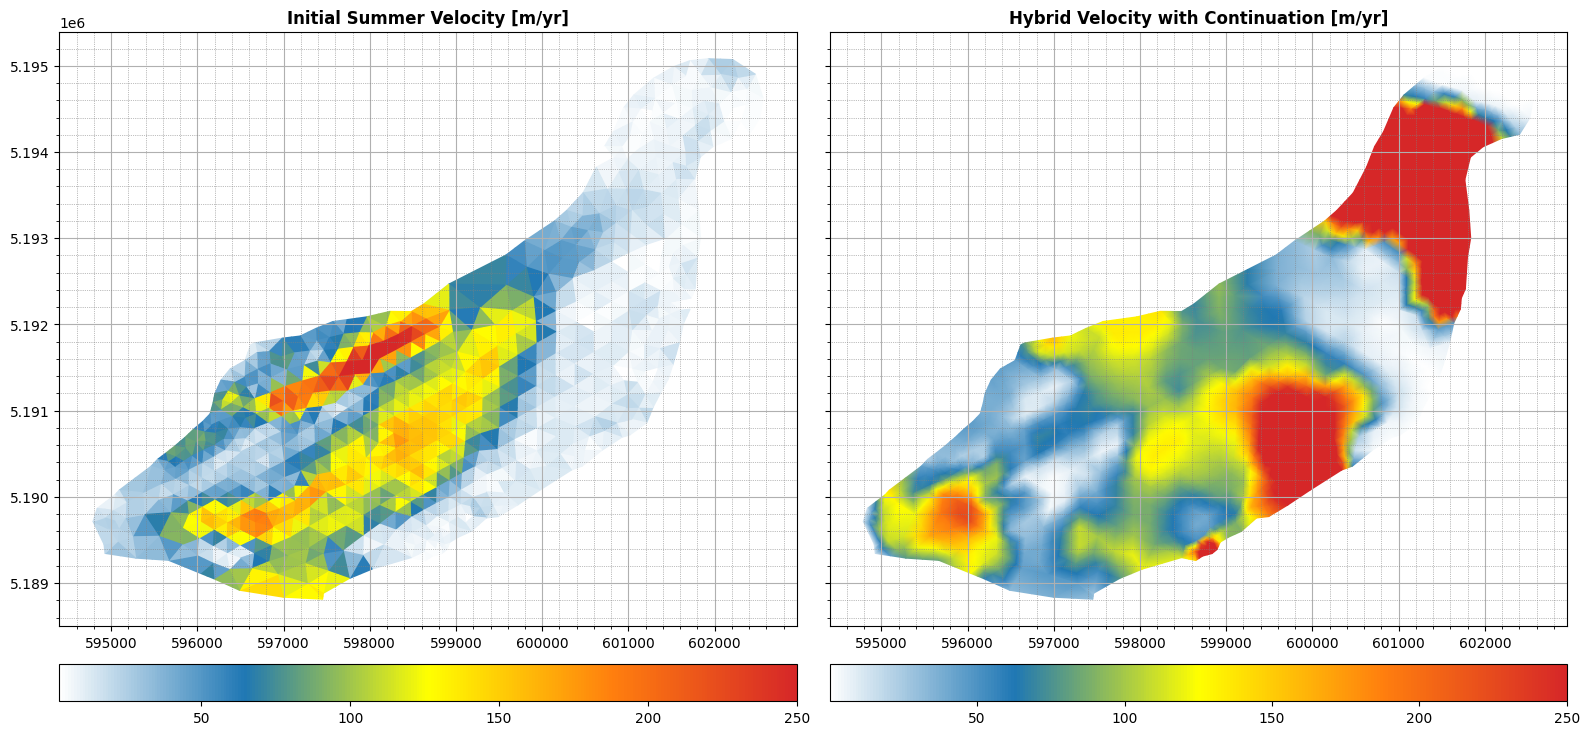

In [36]:
u_init, M_init, τ_init = z.subfunctions

fig, axes = plt.subplots(1, 2, figsize = (16, 10), sharex = True, sharey = True)

axes[0].set_aspect("equal")
colors = firedrake.tripcolor(vs0, 
                             cmap = cmap2, 
                             vmax = 250, 
                             axes=axes[0])
fig.colorbar(colors, fraction=0.046, pad=0.04, orientation = 'horizontal')
axes[0].set_title('Initial Summer Velocity [m/yr]', fontweight = 'bold')
axes[0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0].tick_params(which='both')
axes[0].tick_params(which='major')
axes[0].tick_params(which='minor')
axes[0].yaxis.set_minor_locator(AutoMinorLocator())

axes[0].grid()
axes[0].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

axes[1].set_aspect("equal")
colors = firedrake.tripcolor(u_init, 
                             cmap = cmap2,  
                             vmax = 250,
                             axes=axes[1])
fig.colorbar(colors, fraction=0.046, pad=0.04, orientation = 'horizontal')
#axes[1].clim(0,250)
axes[1].set_title('Hybrid Velocity with Continuation [m/yr]', fontweight = 'bold')
axes[1].xaxis.set_minor_locator(AutoMinorLocator())
axes[1].tick_params(which='both')
axes[1].tick_params(which='major')
axes[1].tick_params(which='minor')
axes[1].yaxis.set_minor_locator(AutoMinorLocator())

axes[1].grid()
axes[1].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

fig.tight_layout()

## Generating an SMB Field
Super basic field w/o debris cover or wind scour

In [37]:
# Using piecewise linear approach with a_max for now\
## Pull relevant state vars
s_min = s.dat.data_ro.min()
s_max = s.dat.data_ro.max()
s_diff = int(np.round(s_max - s_min))

s_vals = np.linspace(s_min, s_max, s_diff)
a_vals = np.zeros(s_diff)

In [38]:
# Set the breakpoints & associated mass balance
a_max = 3
ela = 3200

z = [s_min, ela, s_max] #[s0, ela OR wind_elev, smax]
b_dot = [-7, 3, a_max] # [b_t, b_max, a_max OR wind scour]

windS_elev = z[1]

# Slope calculations
m1 = (b_dot[1] - b_dot[0]) / (z[1] - z[0])         # Normal da/dz
y1_int = b_dot[1] - m1 * z[1]

m2 = (b_dot[2] - b_dot[1]) / (z[2] - z[1])         # Wind scour da/dz
y2_int = b_dot[2] - m2 * z[2]

In [39]:
# Actual expression for the SMB
expr2 = conditional(                               # Below wind scour
    windS_elev >= s,
    (m1 * s) + y1_int,
    0,
)

expr = conditional(                                # Above wind scour
    windS_elev < s,                                 #condition
    min_value(a_max, y2_int + (m2 * s)),
    expr2,                                          # false val
)

# Wrapping it into a function 
def smb2(s):
    return expr

a = firedrake.Function(Q).interpolate(smb2(s))
a.dat.data_ro.sum()

np.float64(-205.1285410817195)

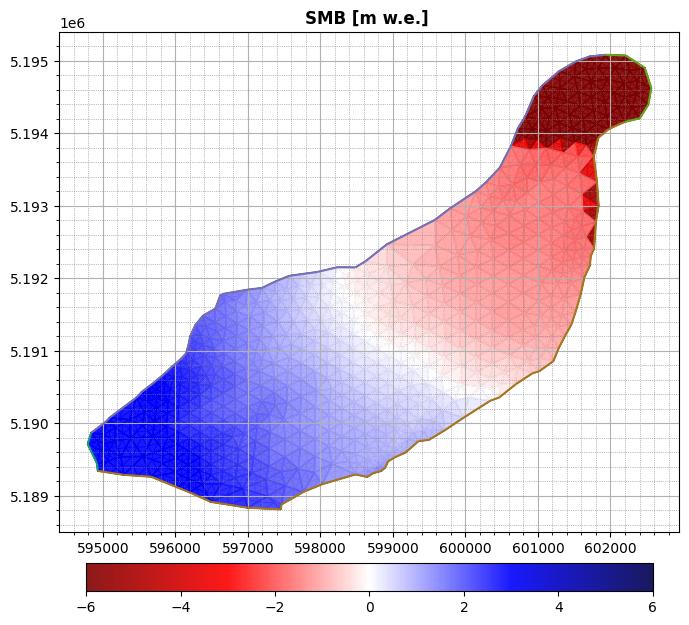

In [40]:
fig, axes = plt.subplots(figsize = (8, 8), sharex = True, sharey = True)

axes.set_aspect("equal")
firedrake.triplot(mesh,
                  axes=axes)
colors = firedrake.tripcolor(a, 
                             vmin = -6,
                             vmax = 6,
                             alpha = 0.9, 
                             cmap = 'seismic_r',
                             axes=axes)

fig.colorbar(colors, fraction=0.046, pad=0.05, orientation = 'horizontal')
axes.set_title('SMB [m w.e.] ', fontweight = 'bold')

axes.xaxis.set_minor_locator(AutoMinorLocator())
axes.tick_params(which='both')
axes.tick_params(which='major')
axes.tick_params(which='minor')
axes.yaxis.set_minor_locator(AutoMinorLocator())

axes.grid()
axes.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

## Run Params

In [41]:
W = V * Σ * T * Q

w = firedrake.Function(W)

w.sub(0).assign(u_init)
w.sub(1).assign(M_init)
w.sub(2).assign(τ_init)
w.sub(3).assign(h);

In [42]:
u, M, τ, h = firedrake.split(w)
v, N, σ, η = firedrake.TestFunctions(W)

Γ = 1e-4

fields = {
    "velocity": u,
    "membrane_stress": M,
    "basal_stress": τ,
    "thickness": h,
    "surface": b + h,
}

F_momentum = (
    momentum_balance(**fields, test_function=v)
    + firedrake.replace(flow_law(**fields, **glen_rheology, test_function=N), {h: H})
    + α * firedrake.replace(flow_law(**fields, **linear_rheology, test_function=N), {h: H})
    + friction_law(**fields, **glen_rheology, test_function=σ)
    + α * friction_law(**fields, **linear_rheology, test_function=σ)
)

F_mass = model.mass_balance(thickness=h, velocity=u, accumulation=a, test_function=η)

F = F_momentum + F_mass

In [43]:
tableau = irksome.BackwardEuler()
dt = Constant(1.0/365.25)

lower = firedrake.Function(W)
upper = firedrake.Function(W)
lower.assign(-np.inf)
upper.assign(+np.inf)
lower.subfunctions[3].assign(0.0)
bounds = ("stage", lower, upper)

vparams = {
    "snes_monitor": ":emmons-output-vi.log",
    "snes_type": "vinewtonrsls",
    "snes_max_it": 250,
    "snes_divergence_tolerance": 1e300,
    "snes_linesearch_type": "l2",
    "snes_linesearch_max_it": 20,
    "ksp_type": "gmres",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

bc = firedrake.DirichletBC(W.sub(0), Constant((0, 0)), inflow_ids)# + side_wall_ids)

bparams = {
    "solver_parameters": vparams,
    "form_compiler_parameters": fc_params,
    "stage_type": "value",
    "basis_type": "Bernstein",
    "bounds": bounds,
}

solver = irksome.TimeStepper(F, tableau, t, dt, w, **bparams)

### Clearing out the pre run jitters 
Before we do long term runs we need to do a shorter one with a much finer timestep to get rid of any weirdness. Without this step the monthly runs will crash.

In [44]:
from tqdm.notebook import trange, tqdm

us = [w.subfunctions[0].copy(deepcopy=True)]
hs = [w.subfunctions[3].copy(deepcopy=True)]
a_s = []
Uc_list = []
final_time = 0.5
num_steps = int(final_time / float(dt))
timesteps = np.linspace(0, final_time, num_steps + 1)
for step in trange(num_steps):
        
    s.interpolate(b + h) 
    
    solver.advance()
    h = w.subfunctions[3]
    #a.interpolate(smb2(b + h))#, δa_δz_noise[step])) # I want to double check that this is doing what I want it to
    t.assign(t + dt)
        
    us.append(w.subfunctions[0].copy(deepcopy=True))
    hs.append(w.subfunctions[3].copy(deepcopy=True))
    a_s.append(a.copy(deepcopy=True))
    Uc_list.append(float(U_c))

  0%|          | 0/182 [00:00<?, ?it/s]

Error: error code 101
[0] SNESSolve() at /opt/petsc/src/snes/interface/snes.c:4906
[0] SNESSolve_VINEWTONRSLS() at /opt/petsc/src/snes/impls/vi/rs/virs.c:537
[0] SNESLineSearchApply() at /opt/petsc/src/snes/linesearch/interface/linesearch.c:643
[0] SNESLineSearchApply_Secant() at /opt/petsc/src/snes/linesearch/impls/secant/linesearchsecant.c:51
[0] SNESComputeFunction() at /opt/petsc/src/snes/interface/snes.c:2497

In [ ]:
# Growth Run w/ no debris
dt.assign(1.0/12)
final_time = 200.0
num_steps = int(final_time / float(dt))
timesteps = np.linspace(0, final_time, num_steps + 1)
#with firedrake.CheckpointFile('emmons-SteadySMBElev_highRes.h5', "w") as chk:
with firedrake.CheckpointFile('emmons-SteadyLoResNew.h5', "w") as chk:
    chk.save_function(w, name="mono", idx=0)
    for step in trange(num_steps):
        
        s.interpolate(b + h) 
    
        solver.advance()
        h = w.subfunctions[3]
        a.interpolate(smb2(b + h))
        t.assign(t + dt)
        
        us.append(w.subfunctions[0].copy(deepcopy=True))
        hs.append(w.subfunctions[3].copy(deepcopy=True))
        a_s.append(a.copy(deepcopy=True))
        Uc_list.append(float(U_c))

        chk.save_function(w, name="mono", idx=step + 1)
                                                                                                      
    chk.save_function(b, name = "bed", idx=step + 1)    
    chk.h5pyfile.create_dataset("timestep", data=timesteps)

In [ ]:
list_O_mons = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

fig, ax = plt.subplots(figsize = (12,6))

ax.plot(list_O_mons, Uc_list[300:313], color = 'tab:green', alpha = 0.4)
ax.scatter(list_O_mons, Uc_list[300:313])

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='both')
ax.tick_params(which='major')
ax.tick_params(which='minor')
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.grid()
ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

ax.set_title('Annual U_c Cycle', fontweight = 'bold')
ax.set_xlabel('Time (Month)', fontweight = 'bold')
ax.set_ylabel('U_c (m/yr)', fontweight = 'bold')

In [ ]:
from firedrake import conditional, And

ablation_mask = conditional(And(h > 0, a < 0), 1, 0)
accumulation_mask = conditional(And(h > 0, a > 0), 1, 0)
ablation_area = firedrake.assemble(ablation_mask * dx)
accumulation_area = firedrake.assemble(accumulation_mask * dx)
AAR = accumulation_area / 11

print(f"Accumulation area: {accumulation_area / 1e6:0.0f} km²")
print(f"Ablation area:     {ablation_area / 1e6:0.0f} km²")
print(f"AAR:               {AAR / 1e6:0.3f}")

In [ ]:
# Calculate volume and mass added through time
volumes = np.array([firedrake.assemble(h*dx) / 1e9 for h in hs])
mass_b = np.array([firedrake.assemble(a*dx) for a in a_s])

In [ ]:
# Steady State Plot
x_steps = np.arange(1, num_steps, 1)
x_steps = x_steps / 12

fig, ax1 = plt.subplots(figsize = (10, 5))
color = 'tab:red'
ax1.set_xlabel('time (YEARS)')
ax1.set_ylabel("Ice Volume ($km^3$)", color=color)
ax1.plot(x_steps, volumes[183:-1], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Accum. Total (m)', color=color)
ax2.plot(x_steps, mass_b[182:-1], color=color, alpha = 0.5)
ax2.tick_params(axis='y', labelcolor=color)

ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(which='both')
ax1.tick_params(which='major')
ax1.tick_params(which='minor')
ax1.yaxis.set_minor_locator(AutoMinorLocator())

ax1.grid()
ax1.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

fig.tight_layout()
plt.show()

In [ ]:
# Park Data Comparison 
park_date = [1896, 1913, 1973, 1994, 2009, 2015] # year
park_vol = [1.2461, 0.7997, 0.6757, 0.681, 0.6608, 0.6648] # km^3

fig, ax = plt.subplots(1, 2, figsize = (12, 6), sharey = True)
color = 'tab:blue'
ax[0].set_title('Model Output')
ax[0].set_xlabel('time (dt)')
#ax[0].set_ylim(0.65, 0.85)
ax[0].set_ylabel("Ice Volume ($km^3$)")
ax[0].plot(volumes, color=color)
ax[0].tick_params(axis='y')

ax[0].xaxis.set_minor_locator(AutoMinorLocator())
ax[0].tick_params(which='both')
ax[0].tick_params(which='major')
ax[0].tick_params(which='minor')
ax[0].yaxis.set_minor_locator(AutoMinorLocator())

ax[0].grid()
ax[0].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

color = 'tab:red'
ax[1].set_title('Park Obs (Not Continuous)')
ax[1].set_xlabel('time (Years)')
#ax[1].set_ylim(0.65, 0.85)
ax[1].axvline(x = 1963, color = 'brown', label = 'Rock Fall')
#ax[1].set_ylabel("Ice Volume ($km^3$)", color=color)
ax[1].plot(park_date[1:-1], park_vol[1:-1], color=color, linestyle ='--')
ax[1].scatter(park_date[1:-1], park_vol[1:-1], color=color)
ax[1].tick_params(axis='y', labelcolor=color)
ax[1].legend()

ax[1].xaxis.set_minor_locator(AutoMinorLocator())
ax[1].tick_params(which='both')
ax[1].tick_params(which='major')
ax[1].tick_params(which='minor')
ax[1].yaxis.set_minor_locator(AutoMinorLocator())

ax[1].grid()
ax[1].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

fig.tight_layout()

In [ ]:
# Difference Calculation

## Thickness
err_expr = (h0_m2 - hs[-1]) 
δh = firedrake.Function(Q).interpolate(err_expr)
δh_smooth = firedrake.project(smoove(δh, λ), Q) # Smooth errors in space

## Velocity 
u_comp = firedrake.Function(V).project(us[-6]) 
err_expr = ((inner(vs0, vs0) ** 0.5) - (inner(u_comp, u_comp) ** 0.5))# ** 2# / mesh.num_cells()
δu = firedrake.Function(Q).interpolate(err_expr)
δu_smooth = firedrake.project(smoove(δu, λ), Q) # Smooth errors in space

In [ ]:
# Final Thickness check to see where 0 thickness exists
fig, axes = plt.subplots(1, 2, figsize = (12,8))

colors = axes[0].imshow(m2_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmin = 0, 
                      vmax = 200,                        
                      axes=axes[0])
fig.colorbar(colors, location = 'right', shrink=0.53, pad=0.02)
axes[0].set_title('M2 Thickness [m]', fontweight = 'bold')
axes[0].set_aspect("equal")
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].set_title('Final Thickness [m]', fontweight = 'bold')
axes[1].set_aspect("equal")
colors1 = firedrake.tripcolor(hs[-1], 
                             num_sample_points=1, 
                             cmap = cmap2,
                             vmin = 0,
                             vmax = 200,
                             shading="flat", 
                             axes=axes[1])
fig.colorbar(colors1, orientation = 'vertical', shrink=0.5, pad = 0.02)
axes[1].set_aspect("equal")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()

In [ ]:
# XY Thickness Plots
fig, axes = plt.subplots(2, 3, figsize = (12,6), sharex = True, sharey = True)
# P1
axes[0, 0].set_title('Initial Projected Thickness [m]', fontweight = 'bold')
axes[0, 0].set_aspect("equal")
colors = firedrake.tripcolor(h0_m2,
                             cmap = 'rainbow',
                             vmax = 300,
                             shading="gouraud",
                             axes=axes[0, 0])
fig.colorbar(colors, orientation = 'vertical', shrink=0.45, pad = 0.03)

#P2
axes[0, 1].set_title('Final Thickness [m]', fontweight = 'bold')
axes[0, 1].set_aspect("equal")
colors1 = firedrake.tripcolor(hs[-1], 
                             num_sample_points=1, 
                             cmap = 'rainbow',
                             vmax = 300,
                             shading="gouraud", 
                             axes=axes[0, 1])
fig.colorbar(colors1, orientation = 'vertical', shrink=0.45, pad = 0.03)

#P3
axes[0,2].set_title('Final Thickness Change [Obs - Model]', fontweight = 'bold')
axes[0,2].set_aspect("equal")
colors = firedrake.tripcolor(δh_smooth, 
                             
                             shading="gouraud",
                             cmap = 'cool',
                             axes=axes[0,2])
fig.colorbar(colors, 
             shrink = 0.45, 
             pad = 0.03, 
             orientation = 'vertical', 
             label = 'm');
axes[0,2].set_xticks([])
axes[0,2].set_yticks([])

#P4
axes[1, 0].set_title('Initial Summer Velocity [m/yr]', fontweight = 'bold')
axes[1, 0].set_aspect("equal")
colors = firedrake.tripcolor(vs0,  
                             vmax = 300, 
                             shading="gouraud",
                             axes=axes[1, 0])
fig.colorbar(colors, orientation = 'vertical', shrink=0.45, pad = 0.03)

#P5
axes[1, 1].set_title('Modeled Summer Velocity [m/yr]', fontweight = 'bold')
axes[1, 1].set_aspect("equal")
colors2 = firedrake.tripcolor(us[-1],
                              vmax = 300, 
                              num_sample_points=1, 
                              shading="gouraud", 
                              axes=axes[1, 1])
fig.colorbar(colors2, orientation = 'vertical', shrink=0.45, pad = 0.03)

#P6
axes[1,2].set_title('Summer Velocity Change [Obs - Model]', fontweight = 'bold')
axes[1,2].set_aspect("equal")
colors = firedrake.tripcolor(δu_smooth,
                             cmap = 'coolwarm',
                              shading="gouraud", 
                              axes=axes[1,2])
fig.colorbar(colors,
             orientation = 'vertical', 
             shrink = 0.45, 
             label = 'm/yr',
             pad = 0.03)
axes[1,2].set_xticks([])
axes[1,2].set_yticks([])


plt.tight_layout()

In [ ]:
vel_plot = [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12]

# Annual Cycle (Model Months)
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(14, 8))
axs = axs.flatten()
for i, ax in enumerate(axs):
    colors = firedrake.tripcolor(us[vel_plot[i]],
                              vmax = 250, 
                              shading="gouraud", 
                              axes=ax)
    fig.colorbar(colors, orientation = 'vertical', shrink=0.6, pad = 0.03)
    ax.set_title(f'Month -{i+1}')
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

In [ ]:
fig = plt.figure(constrained_layout=True)
axs = fig.subplot_mosaic([['Left', 'TopRight'],['Left', 'BottomRight']],
                          gridspec_kw={'width_ratios':[2, 1]})

axs['Left'].set_title('Avg. Velocity')
colors = firedrake.tripcolor(us[-7],
                              vmax = 250, 
                              shading="gouraud", 
                              axes=axs['Left'])
axs['Left'].set_xticks([])
axs['Left'].set_yticks([])
axs['Left'].grid()
axs['Left'].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

axs['TopRight'].set_title('Min. Velocity')
colors = firedrake.tripcolor(us[-10],
                              vmax = 250, 
                              shading="gouraud", 
                              axes=axs['TopRight'])
axs['TopRight'].set_xticks([])
axs['TopRight'].set_yticks([])

axs['BottomRight'].set_title('Max. Velocity')
colors = firedrake.tripcolor(us[-4],
                              vmax = 250, 
                              shading="gouraud", 
                              axes=axs['BottomRight'])
axs['BottomRight'].set_xticks([])
axs['BottomRight'].set_yticks([])

fig.colorbar(colors, ax=[axs['Left'], axs['TopRight'], axs['BottomRight']],
             orientation = 'vertical', 
             shrink=0.8, 
             pad = 0.03, 
             aspect=50,
             label = '(m/yr)')

In [ ]:
slope_steady = firedrake.project(grad(s), B)

fig, ax = plt.subplots(figsize = [8, 8])

colors = firedrake.tripcolor(slope_steady, axes=ax)
fig.colorbar(colors, label="Surface Slope", location = 'right', fraction=0.035, pad=0.04)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

In [ ]:
%%capture

fig, axes = plt.subplots(figsize = (8,8))
axes.set_aspect("equal")

colors = firedrake.tripcolor(hs[0], 
                             vmax= 250, 
                             cmap = 'rainbow',
                             shading="gouraud",
                             num_sample_points=4, 
                             axes=axes)
fig.colorbar(colors, 
             shrink=0.5, 
             pad = 0.02);

In [ ]:
from matplotlib.animation import FuncAnimation

fn_plotter = firedrake.FunctionPlotter(mesh, num_sample_points=4)
def animate(h):
    colors.set_array(fn_plotter(h))

animation = FuncAnimation(fig, animate, tqdm(hs), interval=1e3/60)

In [ ]:
from IPython.display import HTML
HTML(animation.to_html5_video())